In [1]:
!pip install transformers datasets evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.3 MB/s eta 0:00:00


In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader

from transformers import (
    SegformerImageProcessor,
    SegformerForSemanticSegmentation
)

In [3]:
import torch

print(torch.cuda.is_available())

True


In [4]:
from google.colab import drive

drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [5]:
import kagglehub

path = kagglehub.dataset_download("ipythonx/tgrs-road")

print("Path to dataset files:", path)

100%|██████████| 395M/395M [00:03<00:00, 132MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ipythonx/tgrs-road/versions/1


In [6]:
import os

drive_dataset_path = "/content/gdrive/MyDrive/tgrs_road_dataset"

os.makedirs(drive_dataset_path, exist_ok=True)

print("Drive dataset folder ready.")

Drive dataset folder ready.


In [7]:
import shutil

shutil.copytree(
    path,
    drive_dataset_path,
    dirs_exist_ok=True
)

print("Dataset copied to Drive.")

Dataset copied to Drive.


In [9]:
dataset_path = "/content/gdrive/MyDrive/tgrs_road_dataset"

In [10]:
import os

for root, dirs, files in os.walk(dataset_path):

    print("\nFOLDER:", root)

    print("Subfolders:", dirs[:5])

    print("Sample files:", files[:5])

    print("-" * 50)


FOLDER: /content/gdrive/MyDrive/tgrs_road_dataset
Subfolders: ['Train', 'Test', 'Validation']
Sample files: []
--------------------------------------------------

FOLDER: /content/gdrive/MyDrive/tgrs_road_dataset/Train
Subfolders: ['image', 'label', 'centerline']
Sample files: []
--------------------------------------------------

FOLDER: /content/gdrive/MyDrive/tgrs_road_dataset/Train/image
Subfolders: []
Sample files: ['image60.bmp', 'image33.bmp', 'image146.bmp', 'image160.bmp', 'image26.bmp']
--------------------------------------------------

FOLDER: /content/gdrive/MyDrive/tgrs_road_dataset/Train/label
Subfolders: []
Sample files: ['7.bmp', '23.bmp', '14.bmp', '154.bmp', '150.bmp']
--------------------------------------------------

FOLDER: /content/gdrive/MyDrive/tgrs_road_dataset/Train/centerline
Subfolders: []
Sample files: ['new_line20.bmp', 'new_line49.bmp', 'new_line91.bmp', 'new_line40.bmp', 'new_line144.bmp']
--------------------------------------------------

FOLDER: /c

Sample image: image1.bmp
Sample label: 1.bmp


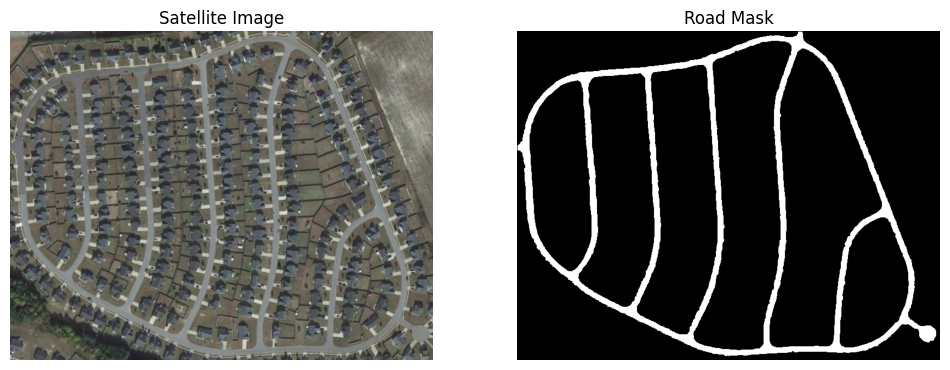

In [11]:
from PIL import Image
import matplotlib.pyplot as plt
import os

image_dir = dataset_path + "/Train/image"
label_dir = dataset_path + "/Train/label"

image_files = sorted(os.listdir(image_dir))
label_files = sorted(os.listdir(label_dir))

print("Sample image:", image_files[0])
print("Sample label:", label_files[0])

img_path = os.path.join(image_dir, image_files[0])
mask_path = os.path.join(label_dir, label_files[0])

img = Image.open(img_path)
mask = Image.open(mask_path)

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Satellite Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Road Mask")
plt.axis("off")

plt.show()

In [12]:
print("First 10 image files:")
print(image_files[:10])

print("\nFirst 10 label files:")
print(label_files[:10])

First 10 image files:
['image1.bmp', 'image10.bmp', 'image100.bmp', 'image101.bmp', 'image102.bmp', 'image103.bmp', 'image104.bmp', 'image105.bmp', 'image106.bmp', 'image107.bmp']

First 10 label files:
['1.bmp', '10.bmp', '100.bmp', '101.bmp', '102.bmp', '103.bmp', '104.bmp', '105.bmp', '106.bmp', '107.bmp']


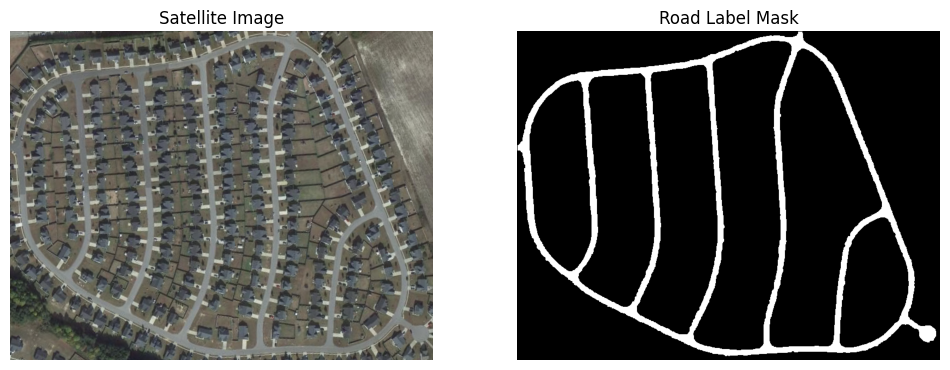

In [13]:
from PIL import Image
import matplotlib.pyplot as plt
import os

# pick a matching pair
image_name = "image1.bmp"
label_name = "1.bmp"

img_path = os.path.join(image_dir, image_name)
mask_path = os.path.join(label_dir, label_name)

img = Image.open(img_path)
mask = Image.open(mask_path)

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Satellite Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Road Label Mask")
plt.axis("off")

plt.show()

In [14]:
train_image_dir = dataset_path + "/Train/image"
train_label_dir = dataset_path + "/Train/label"

train_pairs = []

for image_file in os.listdir(train_image_dir):

    if image_file.endswith(".bmp"):

        number = image_file.replace("image", "").replace(".bmp", "")

        label_file = number + ".bmp"

        image_path = os.path.join(train_image_dir, image_file)
        label_path = os.path.join(train_label_dir, label_file)

        if os.path.exists(label_path):

            train_pairs.append((image_path, label_path))

print("Total training pairs:", len(train_pairs))

print("\nSample pair:")
print(train_pairs[0])

Total training pairs: 160

Sample pair:
('/content/gdrive/MyDrive/tgrs_road_dataset/Train/image/image60.bmp', '/content/gdrive/MyDrive/tgrs_road_dataset/Train/label/60.bmp')


In [15]:
val_image_dir = dataset_path + "/Validation/image"
val_label_dir = dataset_path + "/Validation/label"

val_pairs = []

for image_file in os.listdir(val_image_dir):

    if image_file.endswith(".bmp"):

        number = image_file.replace("image", "").replace(".bmp", "")

        label_file = number + ".bmp"

        image_path = os.path.join(val_image_dir, image_file)
        label_path = os.path.join(val_label_dir, label_file)

        if os.path.exists(label_path):

            val_pairs.append((image_path, label_path))

print("Total validation pairs:", len(val_pairs))

Total validation pairs: 20


In [16]:
from transformers import SegformerImageProcessor

processor = SegformerImageProcessor(
    do_reduce_labels=False
)

In [17]:
class RoadDataset(Dataset):

    def __init__(self, pairs, processor):

        self.pairs = pairs
        self.processor = processor

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):

        image_path, mask_path = self.pairs[idx]

        image = Image.open(image_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        image = np.array(image)
        mask = np.array(mask)

        # Convert mask to binary
        mask = (mask > 0).astype(np.uint8)

        encoding = self.processor(
            images=image,
            segmentation_maps=mask,
            return_tensors="pt"
        )

        pixel_values = encoding["pixel_values"].squeeze()
        labels = encoding["labels"].squeeze()

        return {
            "pixel_values": pixel_values,
            "labels": labels
        }

In [18]:
train_dataset = RoadDataset(train_pairs, processor)
val_dataset = RoadDataset(val_pairs, processor)

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2
)

print("Datasets ready.")

Datasets ready.


In [19]:
from transformers import SegformerForSemanticSegmentation

model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b0-finetuned-ade-512-512",
    num_labels=2,
    ignore_mismatched_sizes=True
)

print("Model loaded.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/15.0M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b0-finetuned-ade-512-512
Key                           | Status   |                                                                                                   
------------------------------+----------+---------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([2])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 256, 1, 1]) vs model:torch.Size([2, 256, 1, 1])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Model loaded.


In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

print(device)

cuda


In [21]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-5
)

In [22]:
from tqdm import tqdm

model.train()

EPOCHS = 5

for epoch in range(EPOCHS):

    total_loss = 0

    loop = tqdm(train_loader)

    for batch in loop:

        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            pixel_values=pixel_values,
            labels=labels
        )

        loss = outputs.loss

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        loop.set_description(f"Epoch {epoch+1}")

        loop.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(train_loader)

    print(f"\nEpoch {epoch+1} Average Loss: {avg_loss:.4f}")

Epoch 1: 100%|██████████| 80/80 [00:16<00:00,  4.96it/s, loss=0.374]



Epoch 1 Average Loss: 0.4859


Epoch 2: 100%|██████████| 80/80 [00:10<00:00,  7.34it/s, loss=0.247]



Epoch 2 Average Loss: 0.2963


Epoch 3: 100%|██████████| 80/80 [00:11<00:00,  7.06it/s, loss=0.188]



Epoch 3 Average Loss: 0.2130


Epoch 4: 100%|██████████| 80/80 [00:11<00:00,  7.12it/s, loss=0.125]



Epoch 4 Average Loss: 0.1659


Epoch 5: 100%|██████████| 80/80 [00:11<00:00,  7.00it/s, loss=0.122]


Epoch 5 Average Loss: 0.1383


In [23]:
test_image_path = val_pairs[0][0]

print(test_image_path)

/content/gdrive/MyDrive/tgrs_road_dataset/Validation/image/image178.bmp


In [24]:
model.eval()

image = Image.open(test_image_path).convert("RGB")

image_np = np.array(image)

inputs = processor(
    images=image_np,
    return_tensors="pt"
)

pixel_values = inputs["pixel_values"].to(device)

with torch.no_grad():

    outputs = model(pixel_values=pixel_values)

logits = outputs.logits

pred_mask = torch.argmax(
    logits,
    dim=1
).squeeze().cpu().numpy()

In [25]:
pred_mask = cv2.resize(
    pred_mask.astype(np.uint8),
    (image_np.shape[1], image_np.shape[0]),
    interpolation=cv2.INTER_NEAREST
)

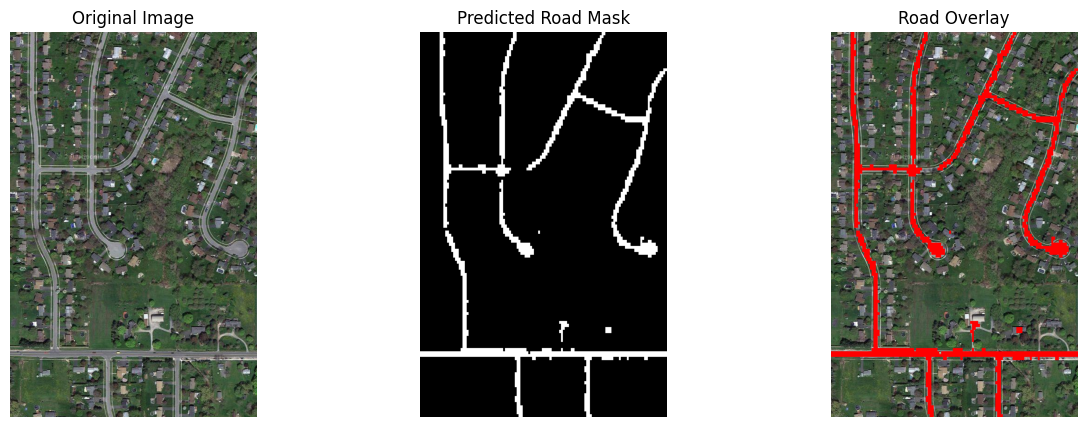

In [26]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(image_np)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(pred_mask, cmap="gray")
plt.title("Predicted Road Mask")
plt.axis("off")

overlay = image_np.copy()

overlay[pred_mask == 1] = [255, 0, 0]

plt.subplot(1,3,3)
plt.imshow(overlay)
plt.title("Road Overlay")
plt.axis("off")

plt.show()

In [27]:
road_pixels = np.sum(pred_mask == 1)

total_pixels = pred_mask.size

road_percent = (road_pixels / total_pixels) * 100

print("Road Coverage Percentage:", round(road_percent, 2), "%")

Road Coverage Percentage: 8.18 %


In [28]:
if road_percent > 20:
    print("Dense road infrastructure detected.")

elif road_percent > 10:
    print("Moderate road connectivity detected.")

else:
    print("Sparse road infrastructure detected.")

Sparse road infrastructure detected.


In [29]:
water_percent = 12  # example from semantic model

if water_percent > 15 and road_percent < 8:

    print(
        "Potential emergency accessibility risk due to low road connectivity near water regions."
    )

In [30]:
from PIL import Image

overlay_image = Image.fromarray(overlay)

overlay_image.save("road_overlay_result.png")

print("Overlay saved.")

Overlay saved.


In [31]:
torch.save(
    model.state_dict(),
    "road_segformer.pth"
)

print("Road model saved.")

Road model saved.


In [32]:
from google.colab import files

files.download("road_segformer.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>